In [ ]:
!pip install langgraph langchain langchain_openai langchain_groq --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.7/126.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 kB 9.5 MB/s eta 0:00:00


In [ ]:
!pip install langchain_community --quiet
%pip install --upgrade --quiet  youtube-transcript-api pytube

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.3/423.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 3.6 MB/s eta 0:00:00


In [ ]:
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPEN_API_KEY')
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_community.document_loaders import YoutubeLoader
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from typing_extensions import TypedDict
from IPython.display import display, Image, Markdown

In [ ]:
# ----------------------
# Define Workflow State
# ----------------------
class State(TypedDict):
    transcript: str
    verified_transcript: str
    blog_content: str
    feedback: str
    video_url: str


In [ ]:
# ----------------------
# LLM Setup
# ----------------------
llm = ChatOpenAI(model="gpt-4")

In [ ]:
# ----------------------
# Node: Transcribe Video
# ----------------------
def transcribe_video(state: State) -> State:
    print("[Transcription] Fetching transcript from YouTube...")
    #state["video_url"] = "https://www.youtube.com/watch?v=Ih1LDnPijFU"
    loader = YoutubeLoader.from_youtube_url(
    state["video_url"], add_video_info=False)
    docs = loader.load()
    transcript_text = "\n".join([doc.page_content for doc in docs])
    state["transcript"] = transcript_text
    return state


In [ ]:
# ----------------------
# Node: Verify Transcript Using LLM
# ----------------------
def verify_transcript(state: State) -> State:
    print("[Verification] Using LLM to check transcript quality and correctness...")
    prompt = ChatPromptTemplate.from_template(
        """
        You are a fact-checking assistant. Given the following transcript from a YouTube video:

        {transcript}

        Please verify the content for correctness and remove any filler or inaccurate information. Return a cleaned-up and accurate version of the transcript.
        """
    )
    chain = prompt | llm
    result = chain.invoke({"transcript": state["transcript"]})
    state["verified_transcript"] = result.content
    return state


In [ ]:

# ----------------------
# Node: Generate Blog Using LLM
# ----------------------
def generate_blog(state: State) -> State:
    print("[Blog Generation] Generating blog post using LLM...")
    prompt = ChatPromptTemplate.from_template(
        """
        You are a blogging assistant. Based on the following verified transcript:

        {verified_transcript}

        Create a well-formatted blog post with:
        - A compelling title
        - Proper section headers
        - Markdown formatting
        - Code blocks if applicable

        Return the blog post as markdown text.
        """
    )
    chain = prompt | llm
    result = chain.invoke({"verified_transcript": state["verified_transcript"]})
    state["blog_content"] = result.content
    return state

In [ ]:
# ----------------------
# Node: Revise Transcript Using LLM
# ----------------------
def revise_transcript(state:State) -> State:
    print("[Revision] Revising transcript using LLM based on feedback...")
    prompt = ChatPromptTemplate.from_template(
        """
        A user has requested a revision of the following transcript:

        {transcript}

        Please make improvements to clarity, conciseness, and accuracy. Provide a cleaned-up version.
        """
    )
    chain = prompt | llm
    result = chain.invoke({"transcript": state["transcript"]})
    state["transcript"] = result.content
    return state


In [ ]:
# # ----------------------
# # Node: Human-in-the-loop Feedback
# # ----------------------
# def get_feedback(state: State):
#     human_response = interrupt("Is the transcript verified (yes/no)?")
#     print(f"Transcript Verified: {human_response}")

#     if (human_response == "yes"):
#         return "Generate Blog"/
#     elif (human_response == "no"):
#         return "Revise Transcript"
#     else:
#         return "Invalid Response"

#     return state

# ----------------------
# Node: Human-in-the-loop Feedback
# ----------------------
def get_feedback(state: State) -> State:
    human_response = interrupt("Is the transcript verified (yes/no)?")
    print(f"Transcript Verified: {human_response}")

    # Update the state dictionary to control the workflow's next step
    if (human_response == "yes"):
        state["feedback"] = "Approved"  # Use "approved" to trigger the correct conditional edge
    elif (human_response == "no"):
        state["feedback"] = "Revise"  # Use a different value to trigger the "Revise" edge
    else:
        state["feedback"] = "invalid"  # Handle invalid responses

    return state  # Return the updated state

In [ ]:
# ----------------------
# Build LangGraph Workflow
# ----------------------
graph = StateGraph(State)

graph.add_node("Transcription", transcribe_video)
graph.add_node("Verification", verify_transcript)
graph.add_node("Huaman Feedback", get_feedback)
graph.add_node("Blog Generation", generate_blog)
graph.add_node("Revision", revise_transcript)

graph.add_edge(START, "Transcription")
graph.add_edge("Transcription", "Verification")
graph.add_edge("Verification", "Huaman Feedback")
graph.add_conditional_edges("Huaman Feedback",
                           lambda state: "Approve" if state["feedback"] == "Approved" else "Revise",
                            {
                                "Approve": "Blog Generation",
                                "Revise": "Revision"
                            })
graph.add_edge("Revision", "Verification")
graph.add_edge("Blog Generation", END)

#Compile the workflow with a checkpointer

memory = MemorySaver()
thread_config = {"configurable": {"thread_id": "unique_thread_id"}}
workflow = graph.compile(checkpointer=memory)

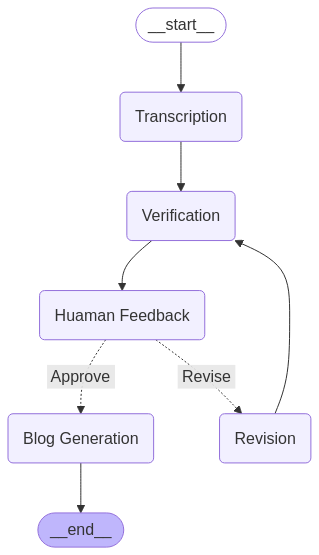

In [ ]:
display(Image(workflow.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
initial_state = {"video_url": "https://www.youtube.com/watch?v=Ih1LDnPijFU"}
first_result = workflow.invoke(initial_state, thread_config, stream_mode="updates")
first_result

[Transcription] Fetching transcript from YouTube...
[Verification] Using LLM to check transcript quality and correctness...


[{'transcription': {'video_url': 'https://www.youtube.com/watch?v=Ih1LDnPijFU',
   'transcript': "hello all my name is krishak and welcome to my YouTube channel so guys yet another amazing video for agentic AI in this specific video we will try to create a video summarization application agentic AI application and here we are going to specifically use a new model that is called as Google Gemini right and I hope everybody knows about Google gemin model so we will try to build it completely end to end uh step by step we'll be going ahead as usual I'll keep the there's some targets for all this agent Ki videos that are coming in this specific Channel at least minimum th000 likes along with that we will also Target it for 200 comments so please make sure that you leave your lovely comments and make sure that you like this particular video and definitely share with many of your friends now before I go ahead I really want to go ahead and share my screen we were discussing about F data uh I w

In [ ]:
print(workflow.get_state(thread_config).next)

('feedback_node',)


In [ ]:
resume_value = input("Should I generate the blog or is there any feedback you want to provide (yes/no)?  ")
second_result = workflow.invoke(Command(resume=resume_value), config=thread_config, stream_mode="updates")
second_result

Should I generate the blog or is there any feedback you want to provide (yes/no)?  yes
Transcript Verified: yes
[Blog Generation] Generating blog post using LLM...


[{'feedback_node': {'transcript': "hello all my name is krishak and welcome to my YouTube channel so guys yet another amazing video for agentic AI in this specific video we will try to create a video summarization application agentic AI application and here we are going to specifically use a new model that is called as Google Gemini right and I hope everybody knows about Google gemin model so we will try to build it completely end to end uh step by step we'll be going ahead as usual I'll keep the there's some targets for all this agent Ki videos that are coming in this specific Channel at least minimum th000 likes along with that we will also Target it for 200 comments so please make sure that you leave your lovely comments and make sure that you like this particular video and definitely share with many of your friends now before I go ahead I really want to go ahead and share my screen we were discussing about F data uh I will take up one more project and we'll start working on this an

In [ ]:
# Access the correct state in the results list
# Assuming 'blog_generation' is the last node executed
state_with_blog_content = second_result[-1]  # Get the last state in the list

# Access the 'blog_content' from the retrieved state
Markdown(state_with_blog_content.get('blog_generation', {}).get('blog_content', ''))

# Title: Let's Build a Video Summarization Application Using Agentic AI: A Guide

Hello everyone, and welcome to another exciting tutorial. Today, we'll create a video summarization application using Agentic AI and Google's Gemini AI model. Let's dive in.

## Introduction

First and foremost, my name is Krishak, and I am the host for this session. I aim to make this guide an interactive one, so your feedback via likes and comments is highly appreciated. Don't forget to share it with anyone might benefit from it.

## Working With Agentic AI

In this tutorial, we are going to use F data, a rich source for AI models. The model of choice for this project is Gemini AI Studio. Each library offers unique attributes that will make our work more manageable and more efficient.

## Boot Camp Announcement

I would also like to quickly announce an upcoming boot camp on building Agentic AI and generative AI applications with Cloud platforms. This series, starting from January 25th, offers participants a deep dive into the world of AI applications and cloud computing, including AWS and GCP platforms.

## Starting our Project

Now that we're all caught up, let's start building. We'll begin by obtaining an API key from Google AI studio. The application we're developing is a 'video summarizer', using this tool, we can upload, analyze, and ask questions on any video file.

## Libraries Used

For this project, our choice of libraries includes Streamlit (`St`), F data, Google Generative AI, and DuckDuckGo search.

Let's begin by importing our libraries:

```python
import Streamlit as St
from F import agent, Gemini, library, DuckDuckGo
from Google.Generative.AI import modules
from pathlib import Path
```

We'll also set up some basic page configuration and initialize our AI agent (referred to as, Gini 2.0 Flash) with specific parameters like the Gemini model and markdown set to True.

```python
St.set_page_config(...)
agent = F.Agent("Gini 2.0 Flash", model=Google.F.Gemini, search_tool=DuckDuckGo, markdown=True)
```

## Video Analysis

After initializing the Agent, we're ready to begin the analysis. We'll create a file uploader for video files (mp4, .mov, .v), ensuring the file size is below 200 MB. 

When analyzing videos larger than 200 MB, an alternative solution is in the pipeline; these solutions will be covered in the upcoming boot camp, where we'll delve into uploading these files to AWS S3 buckets and streaming from there.

```python
uploaded_file = St.file_uploader("Choose a Video file")
```

Once our video file is uploaded and processed, we'll use the AI agent to prompt a video analysis and submit the analysis with the video.

```python
analysis_prompt = "...create prompt..."
agent.submit(analysis_prompt, video=uploaded_file)
```

Then, it's time to run our Streamlit app! Install the required packages in your environment, navigate to your app directory, and start the app with `streamlit run app.py`

## Conclusion

And there you have it! Your very own video summarization application using Agentic AI. I hope you found this module informative and a step forward in your journey with Agentic AI. Be sure to check out the upcoming boot camp, where we'll deep dive into more aspects of AI applications.

Thank you all for joining me, and until next time, happy coding!